# Do the actual fitting marginally.  Separate the gene list into 4 subsets of 6 each.  Track also the time and memory usage in the meanwhile.

In [1]:
%run -i ~/project/preambles
%run -i ~/project/helper_functions
%run -i ~/project/fitting_functions
%load_ext memory_profiler
# # Global parameters:
number_of_cycles = 1000 # how many passes through the training data we go through
number_of_groups = 2 # divide the data set into smaller ones, to make fitting easier.
steps_per_batch = 1
dims = 2  # 2D spatial
head = 5000 # how many locations to consider in the real data set.

cpu


In [2]:
puck_list = ['Puck_230517_39'] # the largest puck
gene_list = [ "Inha", "Inhba", "Inhbb", "Fst", "Esr1", "Esr2", "Pgr", "Ar", "Cyp19a1", 
    "Cyp17a1", "Cyp11a1", "Lhcgr", "Parm1", "Akr1c18", "Fshr", "Star", "Ptgfr", 
    "Sfrp4", "Acvr1", "Acvr2a", "Acvr2b", "Ghr", "Lhb", "Cga"]
adata, X,Y, gene_list=load_data(gene_list=gene_list, head=head, puck_list = puck_list)

['Lhb', 'Cga'] dropped from gene_list due to not being observed.


# Fitting Codes

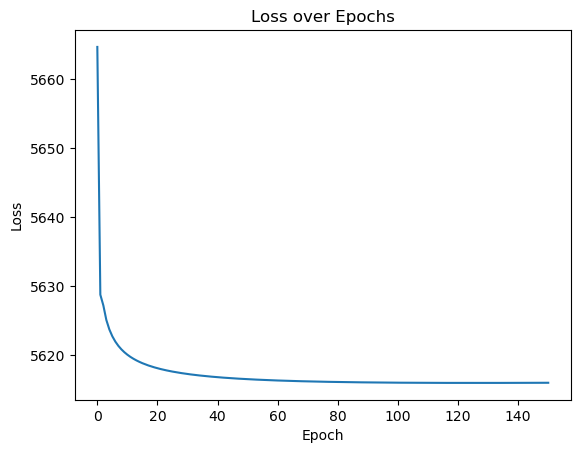

0.09818942833084682 0.8930276399032621 1.2013048131576574


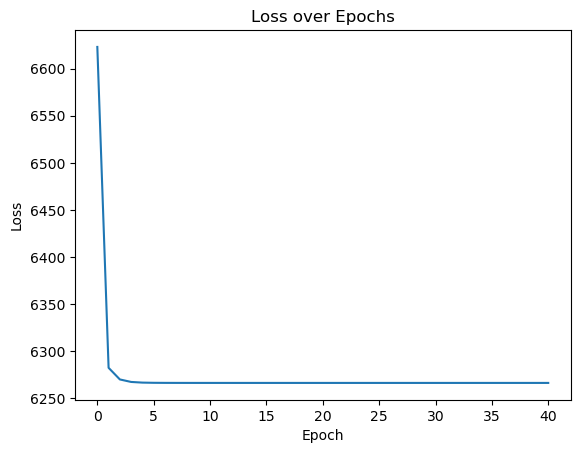

0.10071892352831725 0.8857925679655938 1.3732302540678192


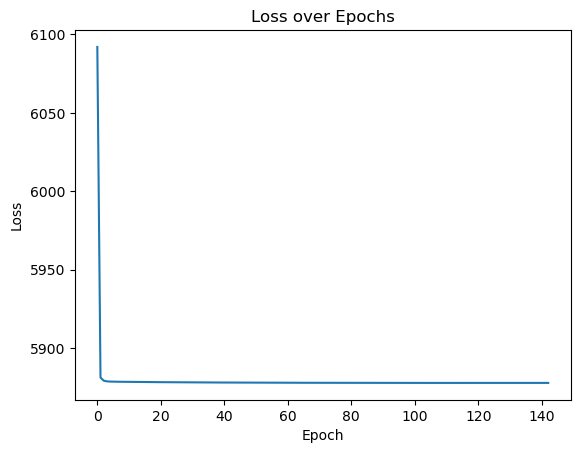

0.09828206673617004 0.88981155546444 1.2532979560478543


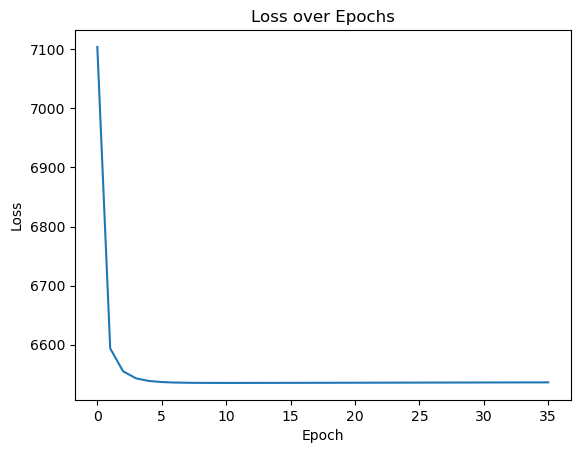

0.10227782678985169 0.8826573732474293 1.457044705709944


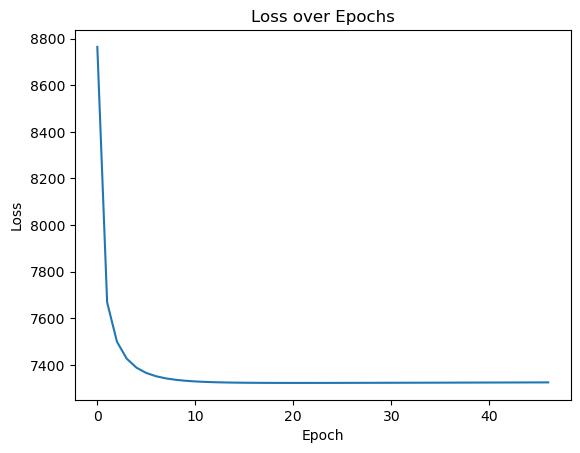

0.10304430637570527 0.8709589686191967 1.709976554602023


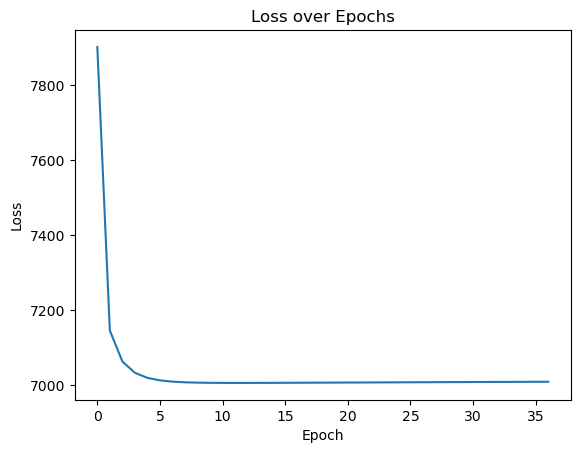

0.10309632580088786 0.8756452633386335 1.611270321330233


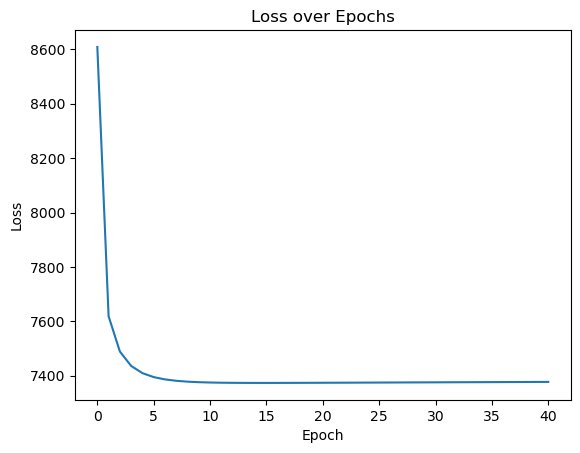

0.10332826561214482 0.8702681399652027 1.7371245412082956


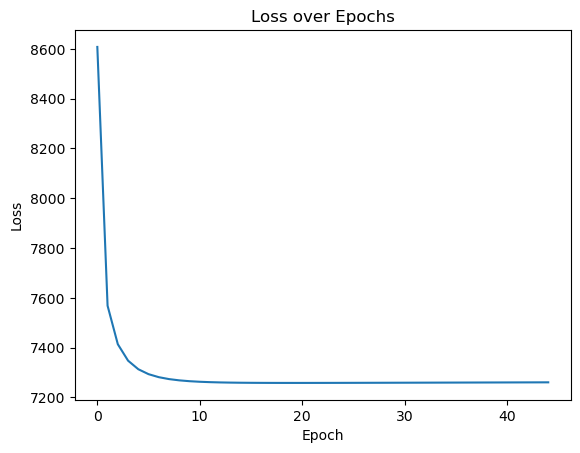

0.10318395619734308 0.8720070140503339 1.689357844383682


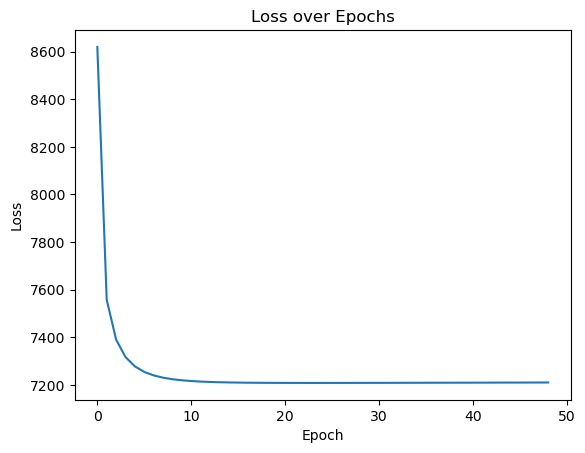

0.1030146987812584 0.873420355067778 1.6691179321609797


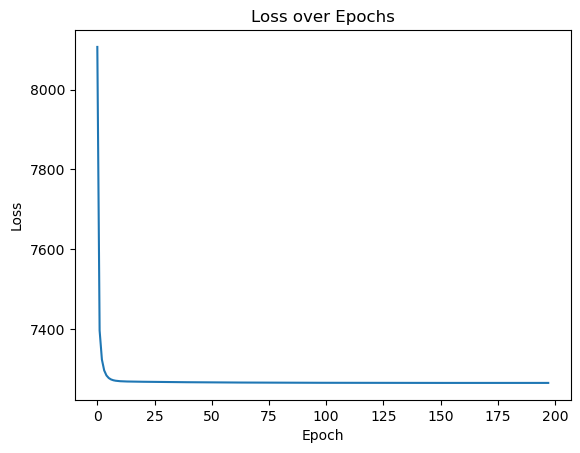

0.10267882545542484 0.8750090775368627 1.699233560376606


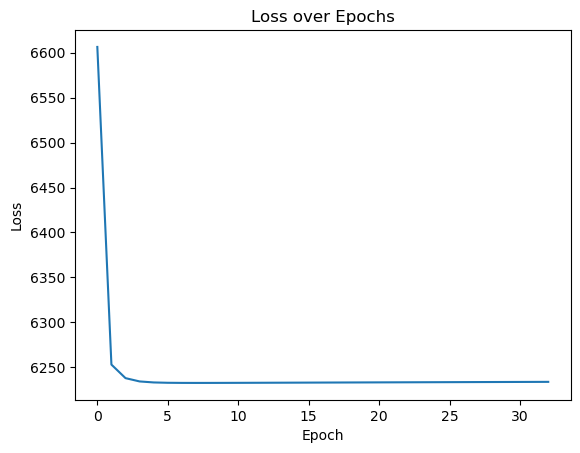

0.10260543359315445 0.8864972700142038 1.3722687451028226


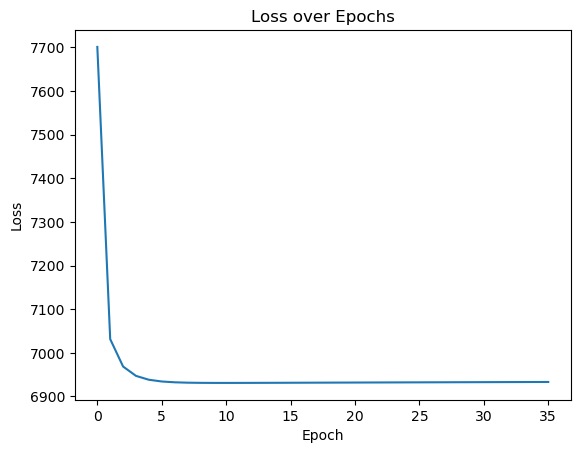

0.10273359664327571 0.8770032841622462 1.5880416987042474


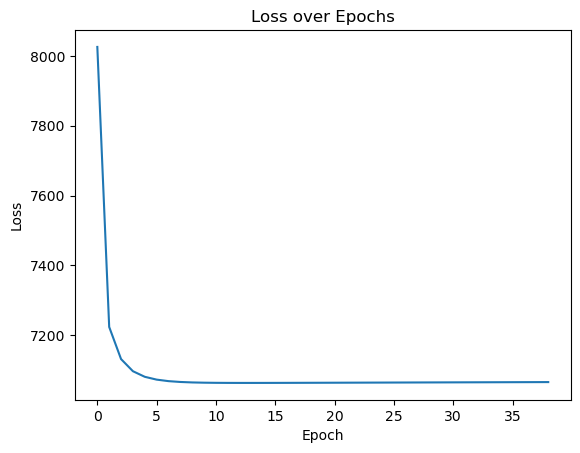

0.10286627472446597 0.8748235234515442 1.62805552914747


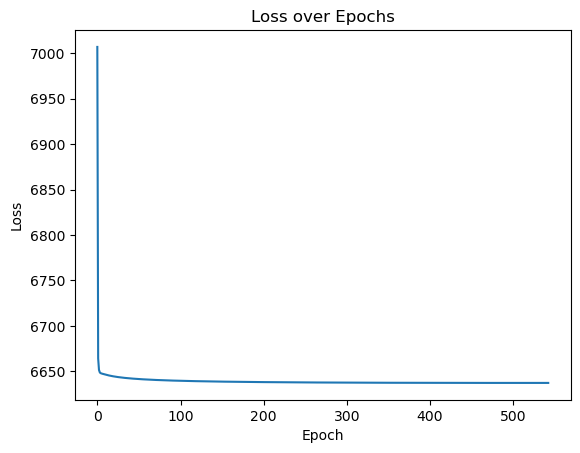

0.10136369619745828 0.8824607955896757 1.4895572316843066


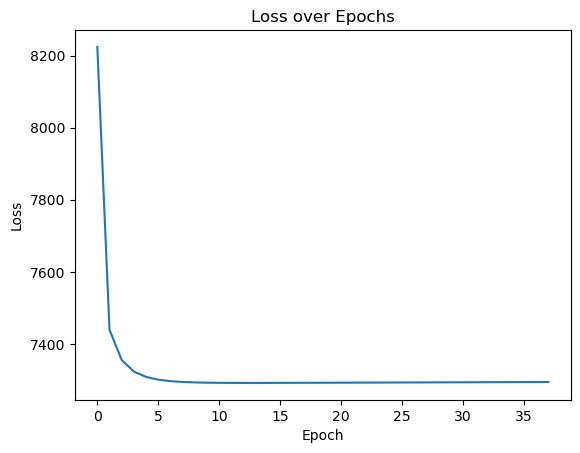

0.10309601443585012 0.8736631075549994 1.713872477848568


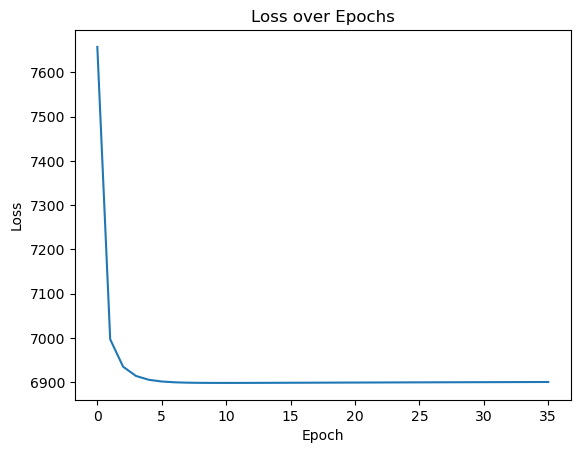

0.10263112877964067 0.8774913697377277 1.5760625842356948


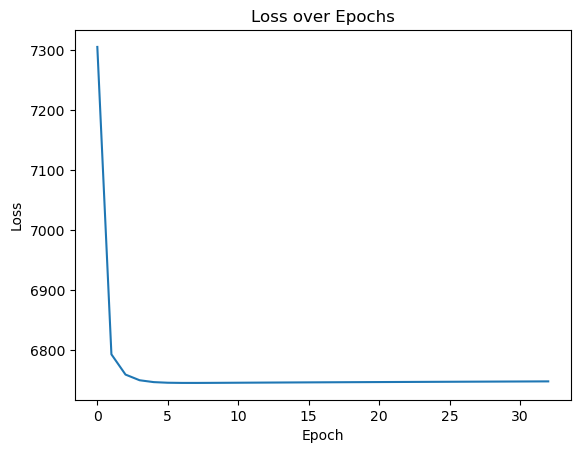

0.10278711410750765 0.8798535061873521 1.5346704714467574


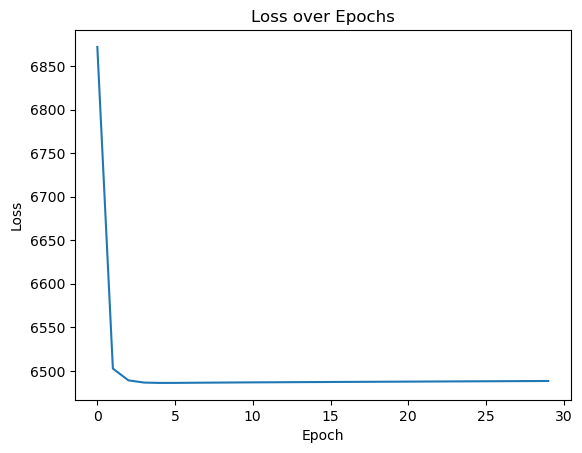

0.10246721761351123 0.883117173911694 1.4570809206725088


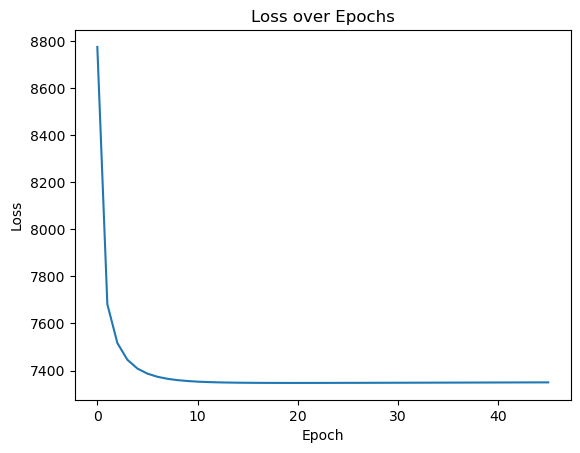

0.10300171365741431 0.8704038098334028 1.7191909032165265


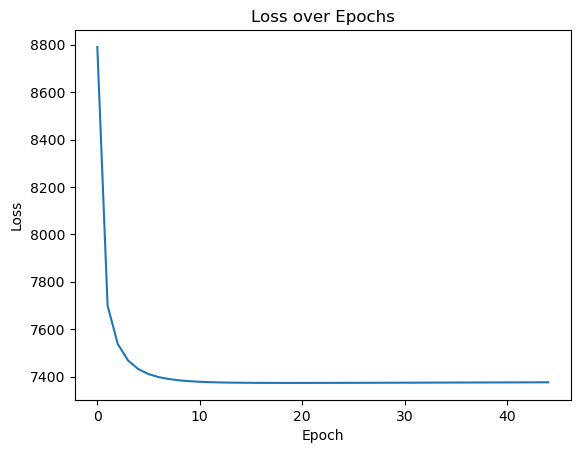

0.1032488955446302 0.8697845852913058 1.7308907219407315


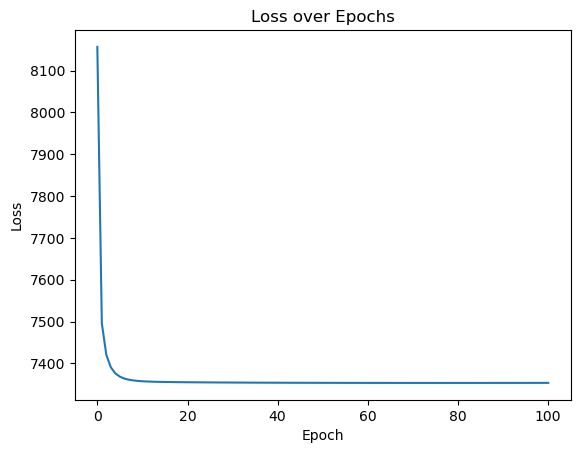

0.10377165642526182 0.8748895338566309 1.7401228212970772


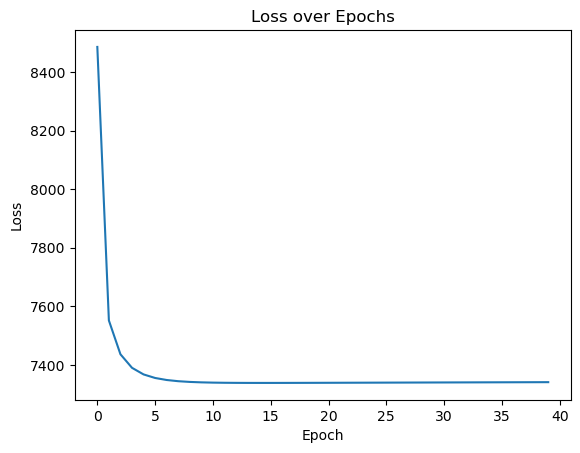

0.1029707325098762 0.8713922688005983 1.7240086229291185
Time taken: 0.179123 hours
peak memory: 2922.74 MiB, increment: 812.09 MiB


In [3]:
%%memit
start_time = time.time()
optimized_marginal_params = optimize_marginal_parameters(X, Y, number_of_groups,  number_of_cycles, steps_per_batch)
end_time = time.time()
print(f"Time taken: {(end_time - start_time)/3600:.6f} hours")

In [4]:
# Run this block only on slurm
df_to_plot = pd.DataFrame(optimized_marginal_params)
notebook_name = "38"
histograms_are_plotted = False
%run -i epilogue

DataFrame saved to /home/zc362/project/python_processed_data/38_job_61872_time_20241027_011227.csv


# The outputs are (alpha_i.item(), nu_i.item(), sigma_i.item()) of the genes.

In [5]:
gene_list

['Inha',
 'Inhba',
 'Inhbb',
 'Fst',
 'Esr1',
 'Esr2',
 'Pgr',
 'Ar',
 'Cyp19a1',
 'Cyp17a1',
 'Cyp11a1',
 'Lhcgr',
 'Parm1',
 'Akr1c18',
 'Fshr',
 'Star',
 'Ptgfr',
 'Sfrp4',
 'Acvr1',
 'Acvr2a',
 'Acvr2b',
 'Ghr']